# 03 — Linkage → Simulated Experiment → Targeting Decision

**Everything from here on is a SIMULATION built on real pre-treatment
covariates.** The risk layer (notebooks 01–02) models real outcomes; the
credit-line experiment and targeting policy below use simulated treatment
and outcomes from a frozen, fully-documented data-generating process (DGP).
Because the DGP is known, every inferential *procedure* can be graded
against ground truth — which is the point: the deliverable is an auditable
decision pipeline, not the simulated numbers themselves.

This notebook READS frozen artifacts (`python -m src.run_linkage`,
`run_layer2`, `run_layer3`); it recomputes nothing, so re-executing it
cannot touch any frozen boundary.

In [1]:
import json
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()))
from src import config  # noqa: E402

ART, FIG = config.ARTIFACTS_DIR, config.FIGURES_DIR
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

## 1. Linkage: calibrated OOF scores → frozen eligibility cohort

Every RISK-DEV customer carries a PD produced by machinery that never saw
their own label: nested cross-fitting (5 outer folds; tuning, WOE,
preprocessing, and the **isotonic calibrator itself** all fit strictly
inside outer-training data via inner cross-fits). A behavioral unit test
flips a fold's labels and requires bit-identical scores for that fold.
Isotonic calibration is order-preserving but introduces ties, which is why
calibrated AUC dips microscopically (0.8654 → 0.8651) while Brier improves.

{'raw OOF': {'roc_auc': 0.8653596179887323,
  'pr_auc': 0.39595208242726376,
  'ks': 0.5716323571672057,
  'brier': 0.049327250742063414,
  'n': 120000,
  'event_rate': 0.06684166666666666},
 'calibrated OOF': {'roc_auc': 0.8650737020449066,
  'pr_auc': 0.39154966366843663,
  'ks': 0.5707812293633845,
  'brier': 0.049242662054284965,
  'n': 120000,
  'event_rate': 0.06684166666666666}}

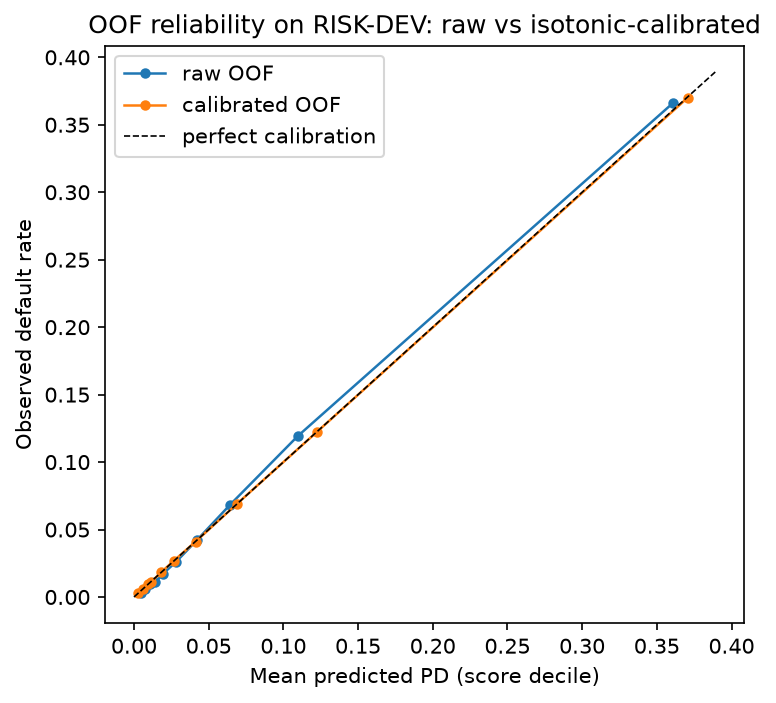

In [2]:
display(json.loads((ART / "oof_calibration_metrics.json").read_text()))
display(Image(str(FIG / "oof_calibration.png")))

The eligibility rule E1–E5 (frozen in `DESIGN_FREEZE.md` §6, absolute E5
threshold recorded before any outcome existed) leaves 94,291 of 120,000
(78.6%). The whole cohort is bound by `linkage_manifest.json` — content
hashes over raw data, split, scores, threshold, and eligible IDs; any
mismatch is a hard error, and the Layer-2 outcome marker forbids cohort
mutation afterwards. "Frozen" is machine-checked, not promised.

In [3]:
display(pd.read_csv(ART / "eligibility_funnel.csv"))

,rule,newly_excluded,remaining
0,start,0,120000
1,E1 90+ DPD >= 1,6448,113552
2,E2 60-89 DPD >= 1,3812,109740
3,E3 30-59 DPD >= 2,3568,106172
4,E4 sentinel rows,229,105943
5,E5 calibrated PD > 0.0904 (p80),11652,94291


## 2. Frozen experiment design and power

Design frozen BEFORE outcome generation (`experiment_design_frozen.json`):
planning control default rate = the eligible cohort's **historical** rate
(2.13%) — a pre-treatment planning proxy, explicitly not an observed control
outcome; spend MDE = \$12 (hypothetical stakeholder input, like δ = 0.50pp);
the pre-registered decision rule; and the full DGP with heterogeneous true
effects (spend effect positive for low-risk eligible, negative near the risk
boundary; incremental default increasing in risk).

**Power is computed at the anticipated true difference.** The frozen DGP
itself anticipates ≈ +0.158pp incremental default, so the distance to the
non-inferiority boundary is δ − 0.158pp, not δ. This is the difference
between a design that is honest with itself and one that isn't:

In [4]:
display(pd.read_csv(ART / "power_analysis.csv"))

,delta_pp,anticipated_true_diff_pp,n_per_arm_spend,n_per_arm_guardrail,n_per_arm_guardrail_zero_diff_scenario,n_per_arm_required,binding_constraint,n_per_arm_available,power_adequate
0,0.3000,0.1581,9480,128020,28650,128020,guardrail,33001,False
1,0.5000,0.1581,9480,22056,10314,22056,guardrail,33001,True
2,0.7500,0.1581,9480,7360,4584,9480,spend,33001,True


At δ = 0.30pp the design is **UNDERPOWERED** (needs ~128k/arm, has 33k) —
reported as such, with the zero-difference n kept only as a labeled
sensitivity scenario. The guardrail is the binding constraint at tight
margins; spend binds at 0.75pp.

## 3. Confirmatory analysis (POLICY-TRAIN ∪ VAL; TEST untouched here)

{'spend_plain': {'diff': 23.882885456834714,
  'se': 2.250808108400277,
  'ci_lo': 19.471301564370172,
  'ci_hi': 28.294469349299256,
  'rel_lift': 0.10285179010460659,
  'n_t': 33001,
  'n_c': 33002,
  'boot_ci': [19.45833591202726, 28.34309961416572]},
 'spend_cuped': {'diff': 25.209842135806895,
  'se': 1.0029436367698898,
  'ci_lo': 23.244072607737913,
  'ci_hi': 27.175611663875877,
  'rel_lift': 0.10887742490090518,
  'n_t': 33001,
  'n_c': 33002,
  'boot_ci': [23.269115793123127, 27.171037217161373],
  'var_reduction': 0.7998879119911473},
 'spend_ancova_hc3_crosscheck': {'diff': 25.210007823404744,
  'se_hc3': 1.003615641278238,
  'ci_lo': 23.242957312178326,
  'ci_hi': 27.177058334631162}}

,delta_pp,observed_diff_pp,one_sided_95_upper_pp,noninferiority,power_adequate
0,0.3000,0.1304,0.3163,NOT DEMONSTRATED,False
1,0.5000,0.1304,0.3163,DEMONSTRATED,True
2,0.7500,0.1304,0.3163,DEMONSTRATED,True


decision rule: SHIP only if BOTH hold on POLICY-TRAIN ∪ POLICY-VAL: (1) CUPED-adjusted spend lift point estimate >= spend_mde_dollars AND its 95% bootstrap CI lower bound > 0; (2) default non-inferiority PASSES at delta_noninf_pp via the one-sided 95% Newcombe upper bound. Otherwise DO NOT SHIP at the ATE level (Layer 3 may still identify a feasible targeted segment policy).
ATE decision: SHIP


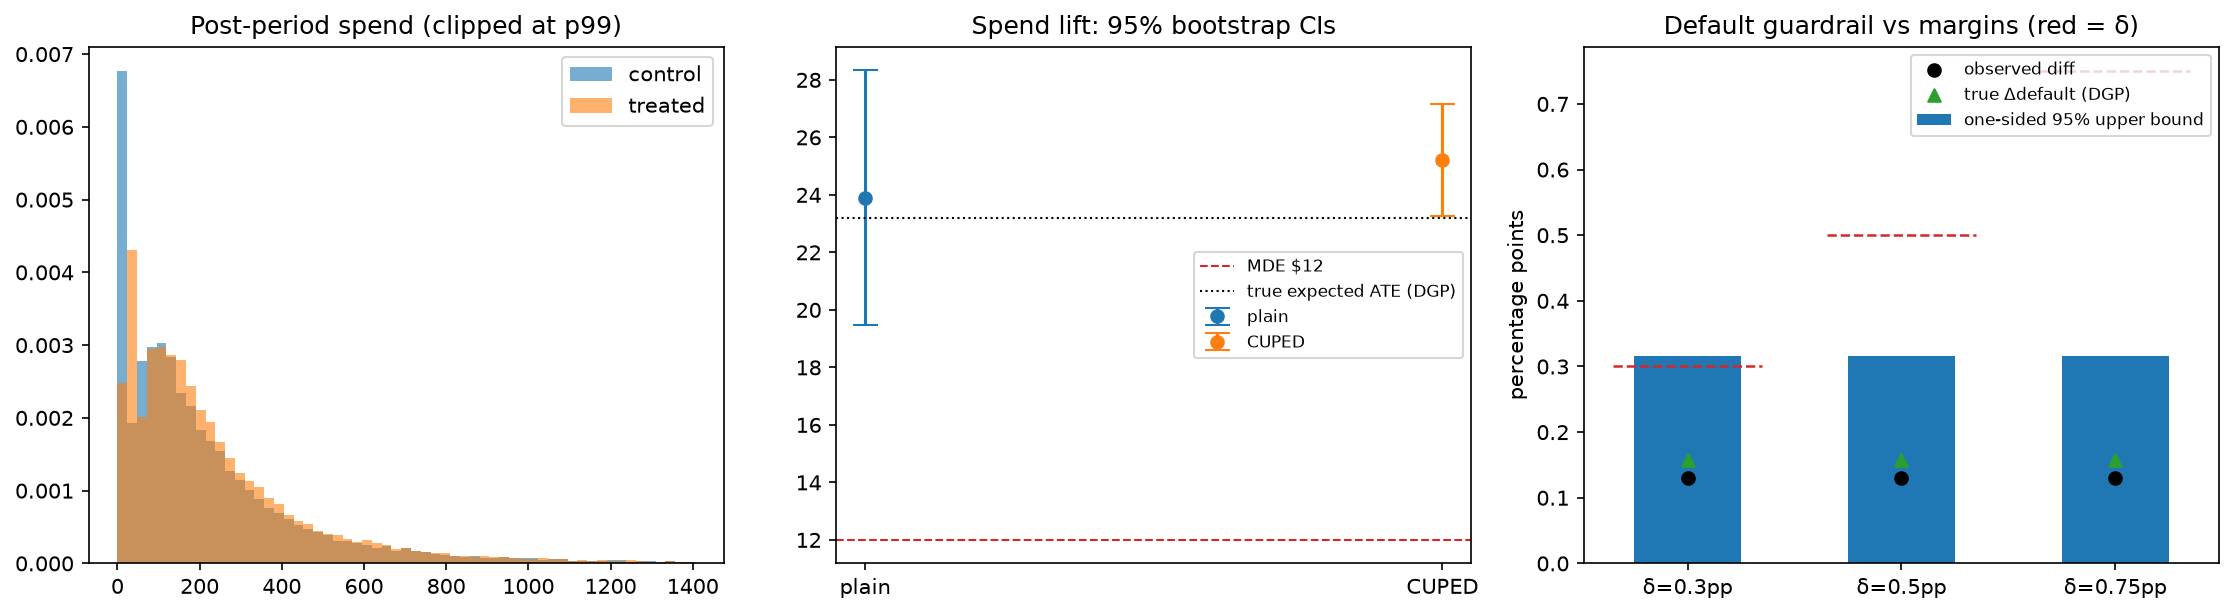

In [5]:
res = json.loads((ART / "layer2_confirmatory_results.json").read_text())
display({k: res[k] for k in ("spend_plain", "spend_cuped",
                             "spend_ancova_hc3_crosscheck")})
display(pd.DataFrame(res["guardrail"]))
print("decision rule:", res["decision_rule"])
print("ATE decision:", res["ATE_decision"])
display(Image(str(FIG / "layer2_results.png")))

Reading this honestly:
- **CUPED** (θ re-estimated inside every bootstrap replicate) cuts the CI
  width by more than half; the ANCOVA + HC3 regression cross-check agrees to
  the cent. The hurdle decomposition and winsorized sensitivity are in the
  artifact.
- **Guardrail:** one-sided 95% Newcombe upper bound = 0.316pp. At the frozen
  0.50pp margin non-inferiority is **DEMONSTRATED** (with adequate power);
  at 0.30pp it is **NOT DEMONSTRATED** — which, per the power table, is what
  an underpowered margin was expected to produce regardless of truth. "Not
  demonstrated" is never read as "proven unsafe."
- Result: **SHIP at the pre-registered 0.50pp margin, while 0.30pp
  non-inferiority was not demonstrated under an underpowered
  tighter-margin design.**

### Validation against DGP truth (simulation privilege)

In [6]:
display(json.loads((ART / "layer2_truth_validation.json").read_text()))

{'note': 'possible ONLY because this is a simulation with known DGP',
 'true_ATE_spend_expected': 23.186225558169138,
 'true_SATE_spend_realized_contrast': 23.14056044066106,
 'true_ATE_spend_tau_only': 22.171846247053693,
 'est_ATE_spend_cuped': 25.209842135806895,
 'est_ATE_spend_plain': 23.882885456834714,
 'cuped_ci_covers_expected_ate': False,
 'cuped_ci_covers_realized_sate': False,
 'plain_ci_covers_expected_ate': True,
 'true_incremental_default_pp': 0.15814918995008515,
 'guardrail_upper_bound_pp': 0.3163160512818725,
 'guardrail_bound_above_truth': True,
 'true_effect_below_frozen_delta': True,
 'guardrail_decision_correct_vs_truth': True}

Two things worth defending in an interview:
- The guardrail's decision is **correct against truth** (true Δdefault
  0.158pp < 0.50pp; the 0.316pp bound sits above the truth, as a valid
  upper bound should).
- The CUPED CI *misses* the expected ATE (+23.19) by \$0.08 while the plain
  CI covers it. Diagnosis: randomization drew a slightly spend-poorer
  treated arm; CUPED's correction was the ex-ante right move, and a 95% CI
  missing ~5% of the time is what 95% means. We report the miss rather than
  choosing the estimator that happened to look better.

## 4. Targeting (Layer 3): individual effects construct the policy;
## safety is validated at the portfolio level

CATE recovery on POLICY-VAL against the **analytic** conditional expected
effect E[Y(1)−Y(0)|X] (never against realized noisy contrasts):

In [7]:
cv = json.loads((ART / "cate_validation.json").read_text())
display(pd.DataFrame({k: {"pehe": v["pehe"], "rank_corr": v["rank_corr"]}
                      for k, v in cv.items()}).T)

,pehe,rank_corr
spend_X,10.1764,0.6543
spend_T,35.2187,0.3369
default_X,1.2521,0.0293
default_T,3.9952,-0.0021


- **Spend:** the X-learner recovers real structure (rank corr 0.65; PEHE
  ~\$10 on an effect ranging ±\$30), and clearly beats the T-learner
  baseline — the expected regime when effects are smoother than outcomes.
- **Default: rank corr ≈ 0.03 — individual default CATEs are statistically
  worthless here, and we say so.** This is the empirical justification for
  the design's central safety choice: no per-customer default guarantee is
  ever claimed; the guardrail is the independent randomized-experiment
  estimate of the POLICY-LEVEL incremental default, with a one-sided upper
  bound against the portfolio tolerance δ.

,share_targeted,inc_spend_per_eligible,inc_default_pp_per_eligible,inc_default_pp_upper_bound,feasible
policy,,,,,
treat_all,1.0000,24.9565,0.1981,0.4822,True
tau_spend_positive,0.9820,25.3626,0.2112,0.4902,True
tau_spend_ge_mde,0.8410,24.1871,0.1043,0.3269,True
low_risk_3quintiles,0.6009,16.7022,0.0860,0.2258,True
tau_pos_and_low_risk,0.4947,14.6194,0.1273,0.2447,True
tau_pos_and_tau_def_low,0.4946,10.4766,0.0778,0.2716,True


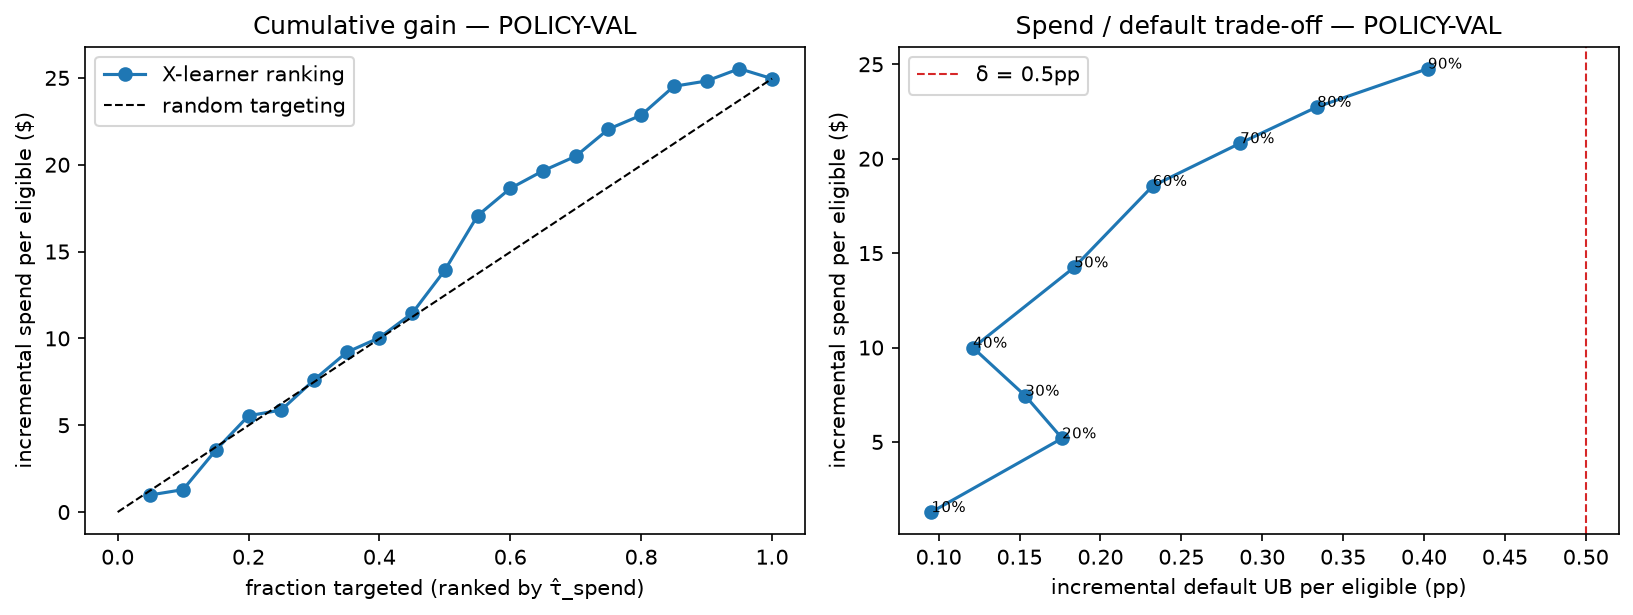

In [8]:
display(pd.read_csv(ART / "policy_candidates_val.csv").set_index("policy")
        [["share_targeted", "inc_spend_per_eligible",
          "inc_default_pp_per_eligible", "inc_default_pp_upper_bound", "feasible"]])
display(Image(str(FIG / "layer3_targeting.png")))

**What the candidate table actually says (restrained reading):** the frozen
winner `tau_spend_positive` targets 98% of eligibles and beats `treat_all`
by **\$0.41 per eligible on VAL — far smaller than the estimation
uncertainty**. This DGP's spend effect is positive for most eligible
customers, so near-broad coverage is genuinely close to optimal, and the
honest description of the outcome is a **near-broad-coverage policy under a
portfolio-level safety constraint** — not a strong-personalization win. The
targeting machinery still earns its keep: the risk-tier gradient is real
(τ̂ falls from ~\$35 in the safest quintile to ~\$12 in the riskiest, where
coverage drops to 93%), and in a world where τ_default had been larger, this
same pipeline is what would have caught it.

### The frozen policy and its single POLICY-TEST evaluation

The policy is an executable, hash-bound artifact: persisted X-learner
boosters + a loadable spec + input-state hashes in `policy_freeze.json`.
Reruns verify-and-load; POLICY-TEST was evaluated exactly once, and the
stored evaluation records the freeze hash it was produced under.

In [9]:
te = json.loads((ART / "policy_test_evaluation.json").read_text())
display({k: te[k] for k in ("policy", "policy_value_test", "truth_validation")})

{'policy': 'tau_spend_positive',
 'policy_value_test': {'share_targeted': 0.9812641402714932,
  'n_targeted_t': 13888,
  'n_targeted_c': 13870,
  'inc_spend_per_eligible': 26.54439478314979,
  'inc_spend_per_eligible_ci': [19.539784829861286, 33.54900473643829],
  'inc_default_pp_per_eligible': -0.0450707971292538,
  'inc_default_pp_upper_bound': 0.23209630326369934,
  'subgroup_spend_diff': 27.051222697087013,
  'subgroup_default_diff_pp': -0.04593136065971365,
  'feasible': True},
 'truth_validation': {'true_inc_default_pp_per_eligible': 0.14870778535537116,
  'true_inc_spend_per_eligible': 23.047169758860466,
  'upper_bound_above_truth': True,
  'true_below_delta': True,
  'guardrail_decision_correct': True}}

In [10]:
display(pd.read_csv(ART / "policy_by_risk_tier.csv", index_col=0))

,n,share_targeted,mean_tau_spend_hat,mean_tau_default_hat_pp
pd_cal,,,,
riskQ1,13381,0.9999,34.8027,0.0505
riskQ2,13881,0.9992,30.9637,0.0774
riskQ3,12402,0.9980,28.0789,-0.2637
riskQ4,13237,0.9832,20.5244,0.1977
riskQ5,13102,0.9276,11.8260,0.2573


**TEST reading:** the frozen policy delivers +\$26.54 incremental spend per
eligible [95% CI 19.5, 33.5] versus **no intervention** — the comparison the
test was designed for; it does **not** establish superiority over
`treat_all`. The portfolio guardrail holds (UB 0.232pp < 0.50pp), and the
DGP truth check confirms the decision was correct (true incremental default
0.149pp; true incremental spend \$23.05, covered by the CI).

## 5. Recommendation

**Ship the credit-line increase broadly to the eligible population, with
the frozen policy's exclusions at the risky margin, under the 0.50pp
portfolio guardrail** — and monitor with exactly the machinery used here:
a randomized holdout and a portfolio-level non-inferiority bound, not
per-customer risk predictions. At a 0.30pp tolerance the honest answer is
"this design cannot demonstrate it; a larger experiment would be required."

---
*Methodological prototype on a public dataset of undocumented provenance;
Layers 2–3 are simulation. See README → Limitations before quoting any
number.*